# 03 - Statistical Analysis

Decomposition, stationarity testing (ADF + KPSS), differencing, ACF/PACF, trend confidence intervals, Ljung-Box autocorrelation testing, and a formal hypothesis test of the seasonal pattern found in the EDA notebook. This is what informs the SARIMA orders chosen in notebook 04.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = Path("../images")

conn = sqlite3.connect(PROCESSED_DIR / "pharma_sales.db")
categories = pd.read_sql("SELECT * FROM dim_category", conn)
CODE_TO_NAME = dict(zip(categories["category_code"], categories["category_name"]))
codes = sorted(CODE_TO_NAME)

## Load monthly data and drop the partial last month

Notebook 02 found October 2019 is a partial month (source data cuts off on the 8th) that reads as a sharp artificial drop in every category. It's dropped here, before any statistical test touches it, rather than left for each later notebook to remember.

In [2]:
monthly = pd.read_sql(
    "SELECT sale_date, category_code, units_sold FROM fact_sales WHERE granularity = 'monthly'",
    conn, parse_dates=["sale_date"]
)
monthly = monthly[monthly["sale_date"] <= "2019-09-30"].sort_values("sale_date")

def get_series(code):
    s = monthly[monthly["category_code"] == code].set_index("sale_date")["units_sold"]
    s = s.asfreq("ME")
    return s

series = {code: get_series(code) for code in codes}
series["N02BE"].tail()

sale_date
2019-05-31    703.562
2019-06-30    610.000
2019-07-31    649.800
2019-08-31    518.100
2019-09-30    984.480
Freq: ME, Name: units_sold, dtype: float64

## Seasonal decomposition

Classical decomposition (period=12) into trend, seasonal, and residual components. Both additive and multiplicative models are fit per category, and the one with lower residual variance (relative to the series' own scale) is selected automatically, since categories differ in whether their seasonal swing grows with the level of the series.

In [3]:
def best_decomposition(s):
    add = seasonal_decompose(s, model="additive", period=12, extrapolate_trend="freq")
    results = {"additive": (add, add.resid.std() / s.mean())}
    if (s > 0).all():
        mul = seasonal_decompose(s, model="multiplicative", period=12, extrapolate_trend="freq")
        results["multiplicative"] = (mul, mul.resid.std())
    best_model = min(results, key=lambda k: results[k][1])
    return best_model, results[best_model][0]

decompositions = {}
for code in codes:
    model_type, result = best_decomposition(series[code])
    decompositions[code] = {"model": model_type, "result": result}

pd.Series({c: decompositions[c]["model"] for c in codes}, name="selected_model")

M01AB          additive
M01AE    multiplicative
N02BA    multiplicative
N02BE    multiplicative
N05B     multiplicative
N05C           additive
R03      multiplicative
R06      multiplicative
Name: selected_model, dtype: str

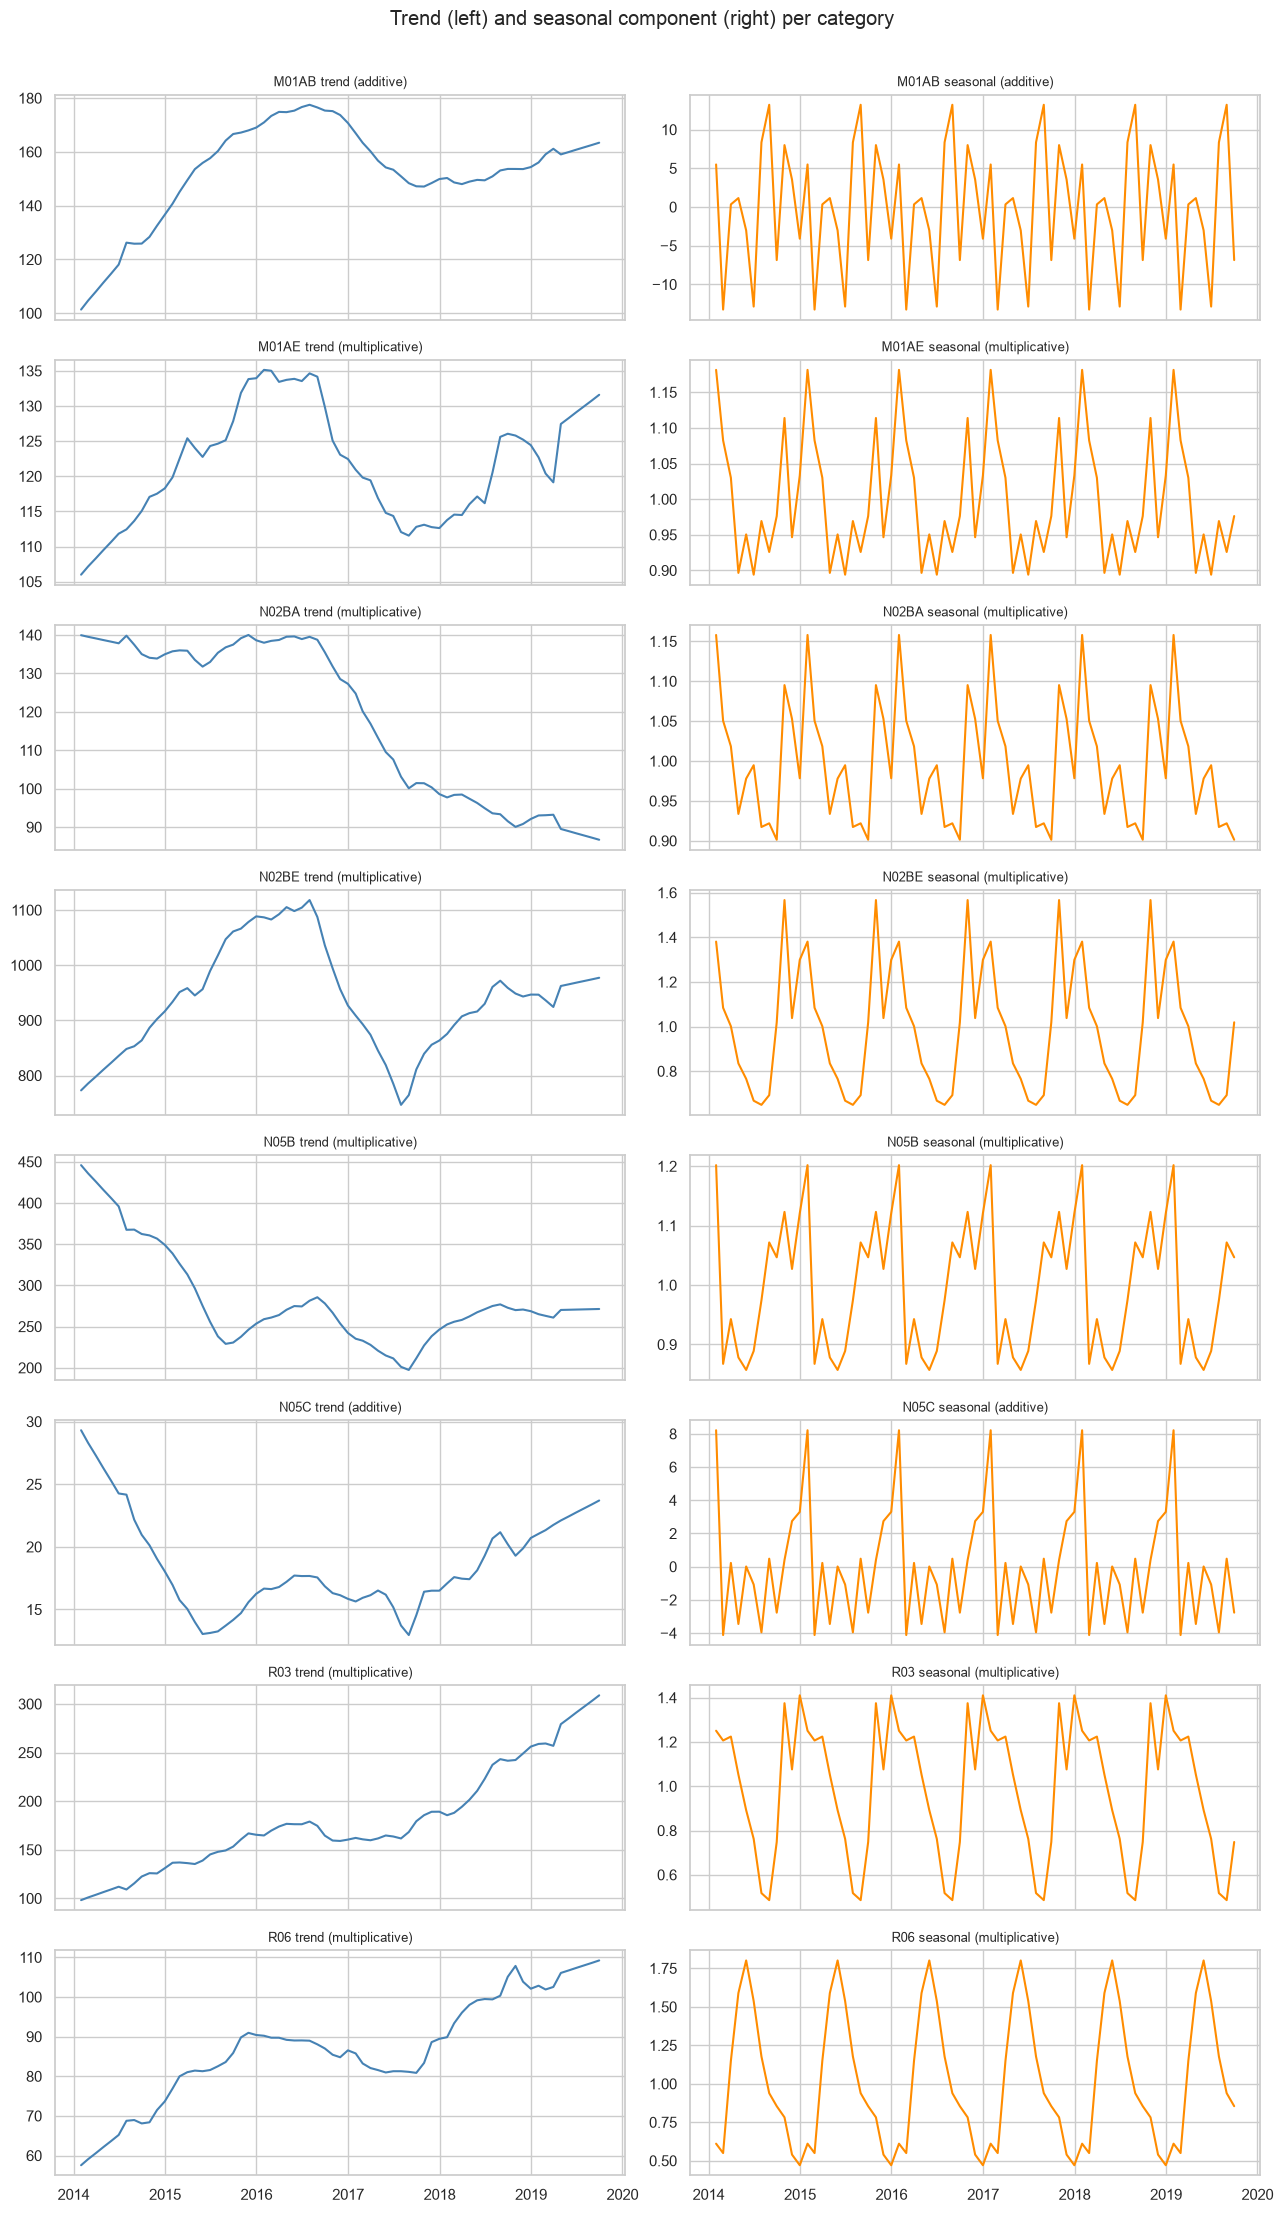

In [4]:
def plot_decomposition(code, ax_cols):
    result = decompositions[code]["result"]
    model = decompositions[code]["model"]
    ax_cols[0].plot(result.trend, color="steelblue")
    ax_cols[0].set_title(f"{code} trend ({model})", fontsize=9)
    ax_cols[1].plot(result.seasonal, color="darkorange")
    ax_cols[1].set_title(f"{code} seasonal ({model})", fontsize=9)

fig, axes = plt.subplots(len(codes), 2, figsize=(13, 22), sharex=True)
for row, code in enumerate(codes):
    plot_decomposition(code, axes[row])

fig.suptitle("Trend (left) and seasonal component (right) per category", y=1.005)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "decomposition_trend_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

## Stationarity: ADF and KPSS

ADF's null hypothesis is "has a unit root" (non-stationary); KPSS's null is the opposite ("is stationary"). Running both avoids trusting a single test — a series that fails both, or that gets contradictory verdicts, needs a closer look rather than a mechanical accept/reject.

In [5]:
def stationarity_tests(s):
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    return {
        "adf_stat": adf_stat, "adf_pvalue": adf_p, "adf_stationary": adf_p < 0.05,
        "kpss_stat": kpss_stat, "kpss_pvalue": kpss_p, "kpss_stationary": kpss_p >= 0.05,
    }

stationarity = pd.DataFrame({code: stationarity_tests(series[code]) for code in codes}).T
stationarity["verdict"] = np.where(
    stationarity["adf_stationary"] & stationarity["kpss_stationary"], "stationary",
    np.where(~stationarity["adf_stationary"] & ~stationarity["kpss_stationary"], "non-stationary", "conflicting")
)
stationarity

/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77363/2328069887.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77363/2328069887.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77363/2328069887.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77

,adf_stat,adf_pvalue,adf_stationary,kpss_stat,kpss_pvalue,kpss_stationary,verdict
M01AB,-2.851975,0.051224,False,0.352749,0.097522,True,conflicting
M01AE,-6.645003,0.0,True,0.147834,0.1,True,stationary
N02BA,-1.93129,0.317487,False,1.17369,0.01,False,non-stationary
N02BE,-4.677788,0.000093,True,0.075157,0.1,True,stationary
N05B,-3.759845,0.003346,True,0.322684,0.1,True,stationary
N05C,-7.355152,0.0,True,0.206203,0.1,True,stationary
R03,-3.719747,0.003844,True,0.652491,0.017864,False,conflicting
R06,-1.097852,0.715928,False,0.227775,0.1,True,conflicting


## Differencing non-stationary series

For every category whose verdict above isn't a clean "stationary", apply first-order differencing and re-run both tests. This determines the `d` term for SARIMA in notebook 04.

In [6]:
diff_needed = stationarity[stationarity["verdict"] != "stationary"].index.tolist()
differenced = {code: series[code].diff().dropna() for code in diff_needed}

diff_results = pd.DataFrame({code: stationarity_tests(differenced[code]) for code in diff_needed}).T
diff_results["verdict"] = np.where(
    diff_results["adf_stationary"] & diff_results["kpss_stationary"], "stationary",
    np.where(~diff_results["adf_stationary"] & ~diff_results["kpss_stationary"], "non-stationary", "conflicting")
)
diff_results

/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77363/2328069887.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77363/2328069887.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77363/2328069887.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/yy/qlwjr6h54jq3x5m3_qcdfz200000gn/T/ipykernel_77

,adf_stat,adf_pvalue,adf_stationary,kpss_stat,kpss_pvalue,kpss_stationary,verdict
M01AB,-7.677336,0.0,True,0.200491,0.1,True,stationary
N02BA,-10.697756,0.0,True,0.124132,0.1,True,stationary
R03,-5.866099,0.0,True,0.051868,0.1,True,stationary
R06,-11.357163,0.0,True,0.021084,0.1,True,stationary


In [7]:
suggested_d = {code: (0 if stationarity.loc[code, "verdict"] == "stationary" else 1) for code in codes}
pd.Series(suggested_d, name="suggested_d")

M01AB    1
M01AE    0
N02BA    1
N02BE    0
N05B     0
N05C     0
R03      1
R06      1
Name: suggested_d, dtype: int64

**Finding:** ADF and KPSS agree cleanly for only 4 of 8 categories at the raw level (M01AE, N02BE, N05B, N05C = stationary; N02BA = non-stationary). M01AB, R03, and R06 get conflicting verdicts — treated conservatively here as needing differencing (`d=1`), which resolves all four differenced series to a clean stationary verdict from both tests. Suggested `d` per category (0 or 1) feeds directly into the SARIMA orders in notebook 04.

## ACF and PACF

Computed on each series after applying the differencing order (`d`) found above, so the plots reflect what will actually be fed into ARIMA — a PACF cutoff after lag p suggests an AR(p) term, an ACF cutoff after lag q suggests an MA(q) term, and a spike at lag 12 in either points to a seasonal term.

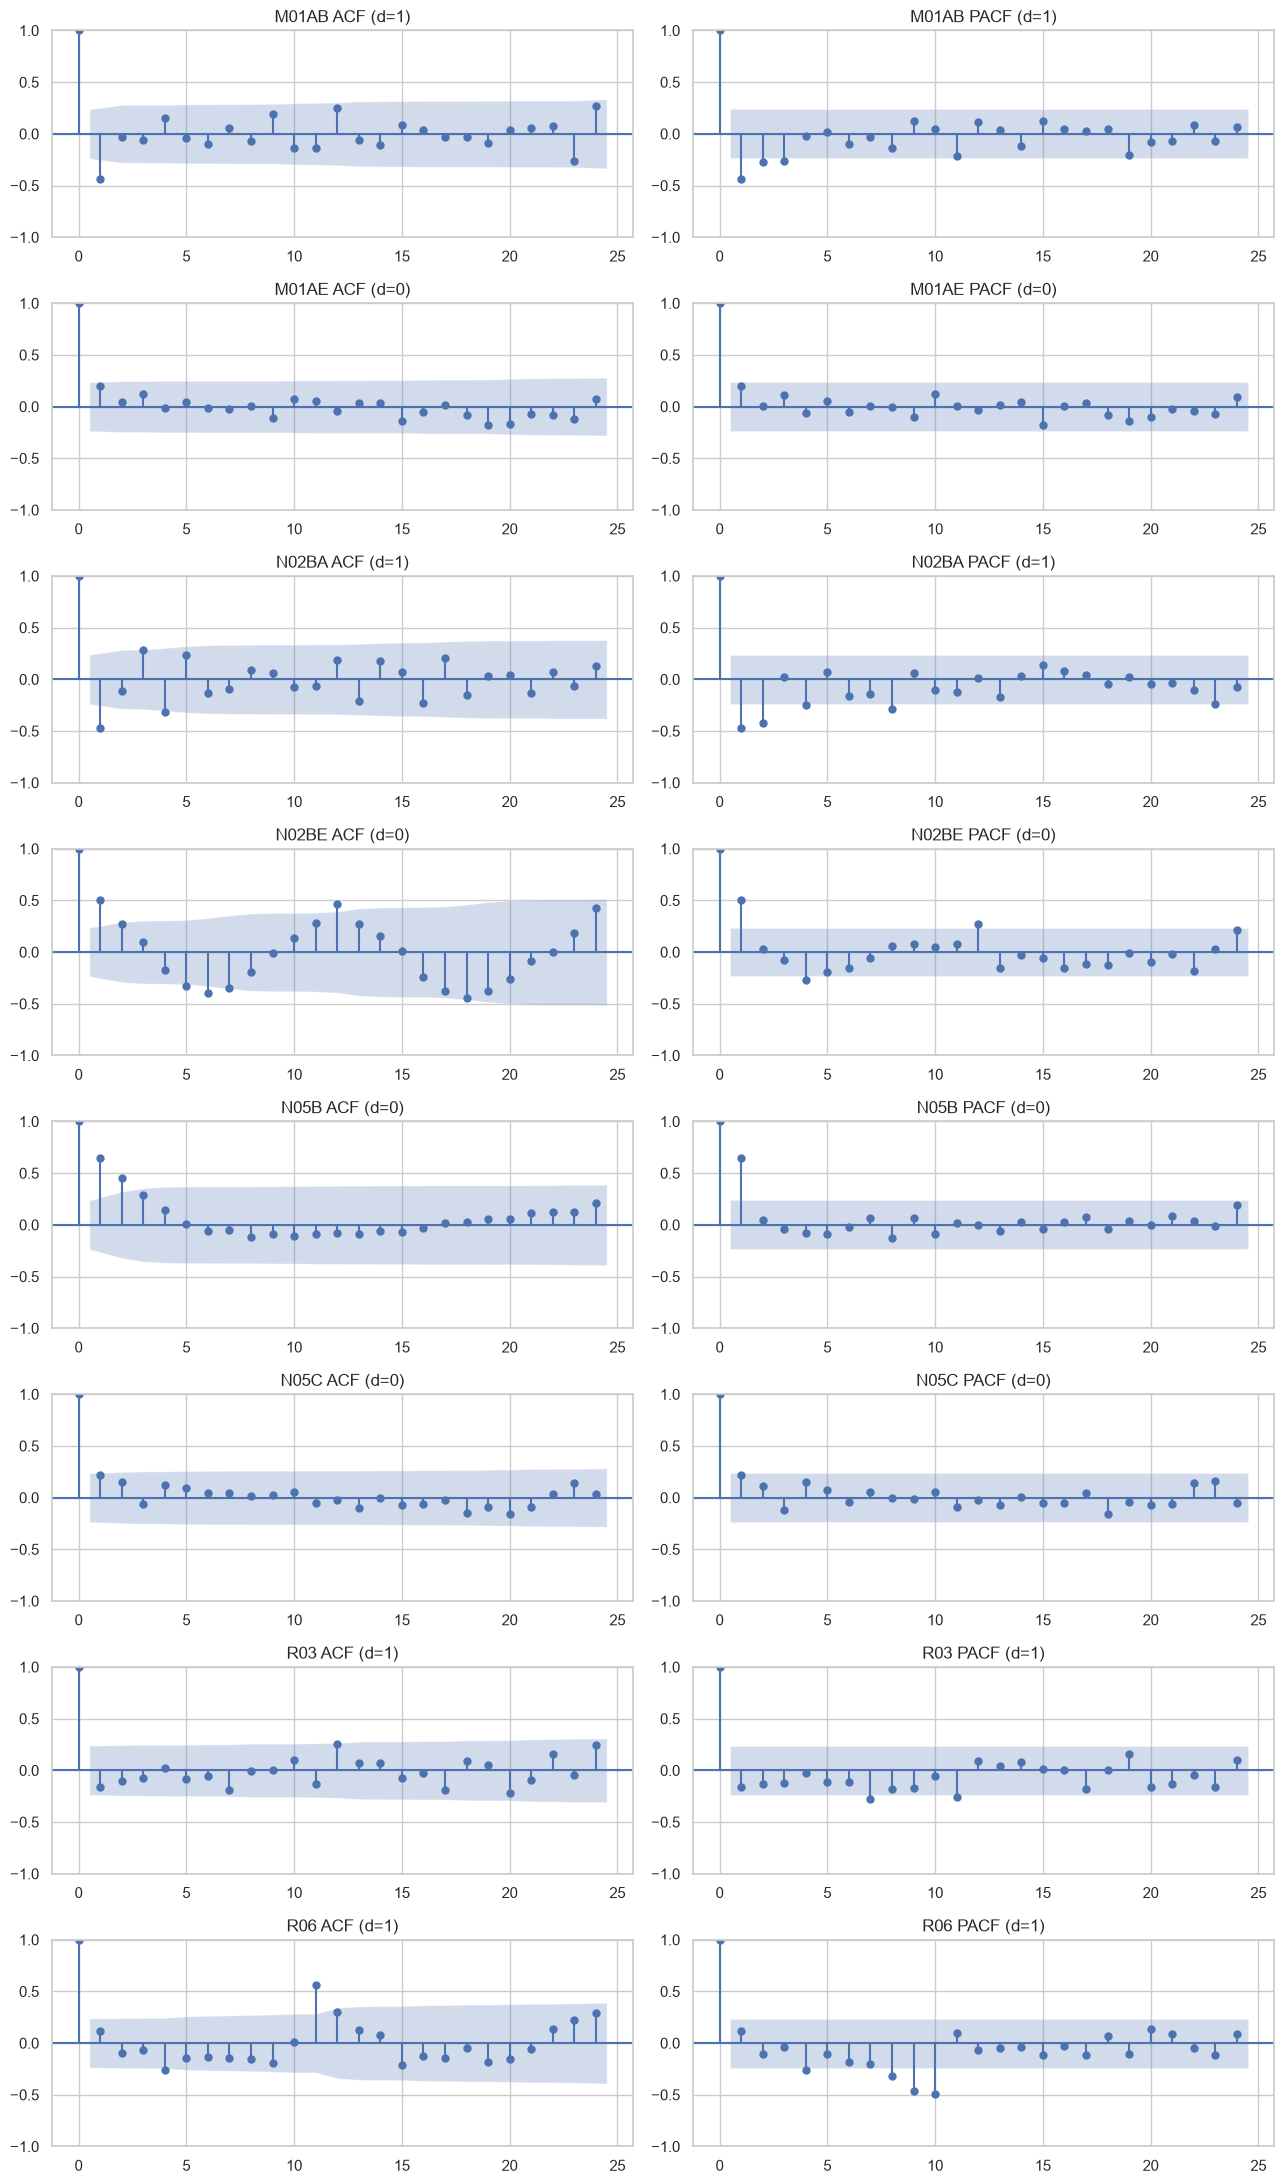

In [8]:
fig, axes = plt.subplots(len(codes), 2, figsize=(13, 22))
for row, code in enumerate(codes):
    s = series[code] if suggested_d[code] == 0 else series[code].diff().dropna()
    plot_acf(s, ax=axes[row, 0], lags=24, title=f"{code} ACF (d={suggested_d[code]})")
    plot_pacf(s, ax=axes[row, 1], lags=24, method="ywm", title=f"{code} PACF (d={suggested_d[code]})")

fig.tight_layout()
fig.savefig(IMAGES_DIR / "acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

## Ljung-Box test on the raw series

Confirms the series actually has autocorrelation worth modeling (as opposed to white noise) before any ARIMA effort is justified. Tested at lag 12 given the monthly seasonal period.

In [9]:
def ljung_box_at_lag12(s):
    result = acorr_ljungbox(s, lags=[12], return_df=True)
    return result.iloc[0]

ljung_box = pd.DataFrame({code: ljung_box_at_lag12(series[code]) for code in codes}).T
ljung_box["has_autocorrelation"] = ljung_box["lb_pvalue"] < 0.05
ljung_box

,lb_stat,lb_pvalue,has_autocorrelation
M01AB,96.226306,3.043717e-15,True
M01AE,6.239506,9.035303e-01,False
N02BA,173.418861,9.532360e-31,True
N02BE,85.887357,3.072194e-13,True
N05B,57.652153,6.025553e-08,True
N05C,8.264226,7.641561e-01,False
R03,69.702755,3.640424e-10,True
R06,183.424267,8.451703e-33,True


**Finding:** 6 of 8 categories show significant autocorrelation at lag 12 (p<0.05) — real structure worth modeling with SARIMA. M01AE and N05C are the exceptions (p=0.90 and p=0.76): their raw monthly series is statistically indistinguishable from white noise at this lag, meaning a full SARIMA is unlikely to beat a much simpler baseline (moving average or even the historical mean) for those two. Worth confirming with the model comparison in notebook 05 rather than assuming SARIMA is always the right tool.

## Trend significance and confidence intervals

OLS regression of units sold on a linear time index per category, giving a slope, its 95% confidence interval, and a p-value for whether the long-run trend is statistically distinguishable from flat.

In [10]:
def trend_stats(s):
    t = np.arange(len(s))
    X = sm.add_constant(t)
    model = sm.OLS(s.values, X).fit()
    ci_low, ci_high = model.conf_int(alpha=0.05)[1]
    return {
        "slope_per_month": model.params[1],
        "ci_low": ci_low, "ci_high": ci_high,
        "p_value": model.pvalues[1],
        "significant_trend": model.pvalues[1] < 0.05,
    }

trend = pd.DataFrame({code: trend_stats(series[code]) for code in codes}).T
trend

,slope_per_month,ci_low,ci_high,p_value,significant_trend
M01AB,0.359107,0.099427,0.618786,0.007443,True
M01AE,-0.024774,-0.297448,0.247901,0.856643,False
N02BA,-0.950668,-1.184304,-0.717032,0.0,True
N02BE,-0.714954,-4.61293,3.183022,0.715443,False
N05B,-1.256686,-2.170372,-0.343,0.007753,True
N05C,-0.021654,-0.123257,0.079949,0.671914,False
R03,1.971221,1.151788,2.790654,0.000009,True
R06,0.594178,0.078118,1.110238,0.024681,True


**Finding:** R03 (respiratory) has the strongest long-run trend by far — +1.97 units/month (95% CI [1.15, 2.79], p<0.0001), meaning demand has been growing steadily across the whole 2014-2019 window, not just seasonally. N02BA (salicylic-acid analgesics) is significantly *declining* (-0.95 units/month, p<0.0001), consistent with its visibly downward-sloping trend panel in notebook 02. N02BE, despite being by far the highest-volume category, has no statistically significant linear trend (p=0.72) — its variation is dominated by the swings already captured in the seasonal/residual components, not a long-run drift.

## Hypothesis test: is the seasonality from notebook 02 statistically real?

The EDA notebook found R03 (respiratory) visibly higher in winter and R06 (antihistamines) visibly higher in spring. Formal two-sample tests here confirm whether those differences hold up, using Welch's t-test (robust to unequal variances) and Mann-Whitney U as a distribution-free cross-check, since 6 monthly observations per season per year is a small sample.

In [11]:
def seasonal_hypothesis_test(code, in_season_months, out_season_months, label):
    s = monthly[monthly["category_code"] == code].copy()
    s["month"] = s["sale_date"].dt.month
    in_season = s[s["month"].isin(in_season_months)]["units_sold"]
    out_season = s[s["month"].isin(out_season_months)]["units_sold"]

    t_stat, t_p = stats.ttest_ind(in_season, out_season, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(in_season, out_season, alternative="two-sided")

    return {
        "comparison": label,
        "in_season_mean": in_season.mean(), "out_season_mean": out_season.mean(),
        "welch_t_pvalue": t_p, "mannwhitney_pvalue": u_p,
        "significant_at_0.05": (t_p < 0.05) and (u_p < 0.05),
    }

hypothesis_results = pd.DataFrame([
    seasonal_hypothesis_test("R03", [10, 11, 12, 1], [6, 7, 8], "R03: winter (Oct-Jan) vs summer (Jun-Aug)"),
    seasonal_hypothesis_test("R06", [4, 5, 6], [11, 12, 1], "R06: spring (Apr-Jun) vs winter (Nov-Jan)"),
])
hypothesis_results

,comparison,in_season_mean,out_season_mean,welch_t_pvalue,mannwhitney_pvalue,significant_at_0.05
0,R03: winter (Oct-Jan) vs summer (Jun-Aug),222.459821,106.111111,1.990011e-06,5.006241e-06,True
1,R06: spring (Apr-Jun) vs winter (Nov-Jan),143.105000,46.555000,3.256214e-10,7.374953e-07,True


**Finding:** both seasonal patterns from the EDA notebook are statistically confirmed, not just visual impressions. R03's winter mean (222.5) is roughly double its summer mean (106.1), Welch's t-test p=2.0e-6. R06's spring mean (143.1) is roughly triple its winter mean (46.6), p=3.3e-10. Mann-Whitney agrees with both at similar significance, so the result isn't an artifact of a normality assumption. This is a solid, defensible basis for using a 12-month seasonal SARIMA term for these two categories in notebook 04.

In [12]:
conn.close()